<a href="https://colab.research.google.com/github/parika8ec-hub/DA_AI_Project5_NLP/blob/main/Project5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Overview:

The 20 Newsgroups dataset is a widely used benchmark dataset for text mining and natural language processing tasks. It contains approximately 20,000 newsgroup documents that are evenly distributed across 20 different categories, each representing a distinct topic such as technology, science, politics, sports, and religion. The dataset is available in scikit-learn and consists of unstructured text data, including email-like messages with subjects, headers, and body content. In this project, the dataset is used for unsupervised learning tasks to explore hidden structures in text data. It serves as the basis for preprocessing, feature extraction using Bag of Words and TF-IDF, and applying clustering techniques like K-Means to group similar documents into meaningful topics.

**Example:**

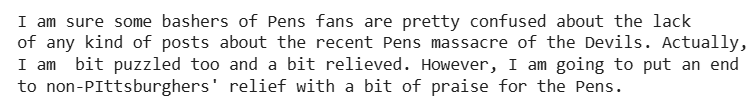

In [9]:
# Import Libraries
import pandas as pd
import numpy as np
import re
import string
import nltk
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# Install library
!pip install gensim
from gensim.models import Word2Vec
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# Task-1: Text Data Preparation

**Load the Newsgroups dataset using scikit-learn**

In [10]:
# Download the tokenizer package required for splitting text into words
nltk.download('punkt')

# Download the list of common stopwords like the, is, and
nltk.download('stopwords')

# Load the complete 20 Newsgroups dataset from scikit-learn
newsgroups20 = fetch_20newsgroups(subset='all')

# Store all text documents from the dataset into a variable
text_documents = newsgroups20.data

# Display the total number of documents in the dataset
print("Total Documents:", len(text_documents))

# Display the first 500 characters of the first document as a sample
print("\nSample Document:\n", text_documents[0][:500])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total Documents: 18846

Sample Document:
 From: Mamatha Devineni Ratnam <mr47+@andrew.cmu.edu>
Subject: Pens fans reactions
Organization: Post Office, Carnegie Mellon, Pittsburgh, PA
Lines: 12
NNTP-Posting-Host: po4.andrew.cmu.edu



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killin


**Perform Text preprocessing (tokenization, removing stopwords and punctuation)**


In [11]:
# Download additional tokenizer resource without showing download messages
nltk.download('punkt_tab', quiet=True)

# Load English stopwords and convert them into a set for faster lookup
stop_words = set(stopwords.words('english'))

# Create a function to clean and preprocess text
def preprocess_text(text):

    # Convert all characters in the text to lowercase
    lower_text = text.lower()

    # Remove punctuation, special characters and numbers using regex
    clean_text = re.sub(r'[^a-zA-Z\s]', '', lower_text)

    # Split text into individual words/tokens
    tokens = word_tokenize(clean_text)

    # Remove common stopwords from the token list
    clean_tokens = [word for word in tokens if word not in stop_words]

    # Join cleaned tokens back into a single string
    return " ".join(clean_tokens)

# Apply preprocessing to the first 5000 documents for faster execution
cleaned_docs = [preprocess_text(doc) for doc in text_documents[:5000]]

#Display first 300 characters of the first cleaned document
print("Preprocessed Sample:\n", cleaned_docs[0][:300])

Preprocessed Sample:
 mamatha devineni ratnam mrandrewcmuedu subject pens fans reactions organization post office carnegie mellon pittsburgh pa lines nntppostinghost poandrewcmuedu sure bashers pens fans pretty confused lack kind posts recent pens massacre devils actually bit puzzled bit relieved however going put end no


# Task-2: Text Representation

Bag of Words (BoW) and TF-IDF are two common methods used to convert text data into numerical form for machine learning models.

Bag of Words represents text by counting how many times each word appears in a document, without considering grammar or word order, resulting in a simple frequency-based vector.

In contrast, TF-IDF (Term Frequency-Inverse Document Frequency) improves this approach by assigning higher importance to words that are frequent in a specific document but rare across the entire dataset.

This helps reduce the weight of common words and highlights more meaningful terms, making TF-IDF more effective for text analysis and clustering tasks.

**Bag of Words implementation for feature extraction**

In [12]:
# Create a Bag of Words vectorizer and keep the top 5000 most frequent words
bow_vectorizer = CountVectorizer(max_features=5000)

# Convert the cleaned text documents into numerical Bag of Words features
X_bow = bow_vectorizer.fit_transform(cleaned_docs)

# Display the shape of the resulting matrix as documents × features
print("Bag of Words Shape:", X_bow.shape)
print("\nDisplay first few bag of words:",X_bow[0].toarray())

Bag of Words Shape: (5000, 5000)

Display first few bag of words: [[0 0 0 ... 0 0 0]]


**TF-IDF implementation for feature extraction**

In [13]:
# Create a TF-IDF vectorizer and keep the top 5000 most important words/features
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Convert the cleaned text documents into TF-IDF feature vectors
X_tfidf = tfidf_vectorizer.fit_transform(cleaned_docs)

#Display the shape of the TF-IDF matrix as documents × features
print("TF-IDF Shape:", X_tfidf.shape)
print("\nDisplay first few TF-IDF:", X_tfidf[0].toarray())

TF-IDF Shape: (5000, 5000)

Display first few TF-IDF: [[0. 0. 0. ... 0. 0. 0.]]


**Implement basic word embeddings**

In [14]:
# Split each cleaned document into individual words/tokens
tokenized_docs = [doc.split() for doc in cleaned_docs]

# Train a Word2Vec model on the tokenized documents
word2vec_model = Word2Vec(
    # Input tokenized sentences/documents
    sentences=tokenized_docs,
    # Set the size of each word vector to 50 dimensions
    vector_size=50,
    # Consider 5 surrounding words as context
    window=5,
    # Ignore words that appear fewer than 2 times
    min_count=2,
    # Use 4 CPU cores for faster training
    workers=4)

print("Word Embedding:")

# Display the target word being checked
print("\nVector for 'computer':")

# Check if the word 'computer' exists in the trained vocabulary
if "computer" in word2vec_model.wv:
    #Display the first 10 values of the word vector for 'computer'
    print(word2vec_model.wv["computer"][:10])

else:
    #Display message if the word is not found in vocabulary
    print("'computer' not found in vocabulary")

Word Embedding:

Vector for 'computer':
[ 1.071804   -1.5074884   0.10494582  1.9049678   0.14176519  0.6511552
  2.2313578  -0.6235718  -4.6702127   0.24260004]


# Task-3: Unsupervised Learning Application

**Apply clustering algorithms as K-Means to the extracted features**

**Note:**
- K-Means clustering was used in this project due to its efficiency and suitability for large, high-dimensional text data such as TF-IDF features. It is computationally faster and scales well with the 20 Newsgroups dataset, making it ideal for document clustering.

- Hierarchical clustering was not used for the full dataset because it is computationally expensive and requires significantly more memory and processing time, especially for large datasets. Therefore, it was avoided in favor of K-Means to ensure faster and more practical execution while still achieving meaningful clustering results.

- The number of clusters (n_clusters = 20) was chosen because the 20 Newsgroups dataset contains 20 predefined topic categories. This allows the K-Means algorithm to align with the dataset's natural structure, making results easier to interpret and compare with actual topics. It also helps each cluster represent meaningful themes such as politics, sports, technology.

In [15]:
# Create a K-Means clustering model with 20 clusters
kmeans = KMeans(n_clusters=20, random_state=42)

# Train the K-Means model using TF-IDF feature data
kmeans.fit(X_tfidf)

# Store the cluster labels assigned to each document
clusters = kmeans.labels_

print("Cluster Labels:")
# Display cluster labels of the first 20 documents
print(clusters[:20])

Cluster Labels:
[16 18 14  2  2  4  5 16  7  9  7 12  7  4  7 14  2 10  0 10]


**Analyze and interpret the resulting clusters, examining common themes/topics within each cluster**

In [21]:
# Calculate the silhouette score to evaluate clustering performance
sil_score = silhouette_score(X_tfidf, clusters)

#Display the silhouette score rounded to 2 decimal places
print("Silhouette Score:", round(sil_score, 2))

Silhouette Score: 0.01


In [17]:
# Get all feature names/words created by the TF-IDF vectorizer
terms = tfidf_vectorizer.get_feature_names_out()

print("\nTop Terms in Each Cluster:")

# Loop through all 20 clusters
for i in range(20):

    # Get index of top 10 highest-weight words in the current cluster center
    center_terms = kmeans.cluster_centers_[i].argsort()[-10:][::-1]

    # Convert index into actual word names
    top_words = [terms[ind] for ind in center_terms]

    #Display cluster number and its top representative words
    print(f"Cluster {i}: {top_words}")


Top Terms in Each Cluster:
Cluster 0: ['people', 'fbi', 'waco', 'government', 'fire', 'would', 'koresh', 'gun', 'batf', 'gas']
Cluster 1: ['sale', 'offer', 'condition', 'email', 'shipping', 'distribution', 'asking', 'price', 'new', 'lines']
Cluster 2: ['drive', 'scsi', 'ide', 'hard', 'drives', 'mb', 'disk', 'controller', 'floppy', 'hd']
Cluster 3: ['windows', 'dos', 'file', 'nt', 'run', 'files', 'win', 'running', 'memory', 'program']
Cluster 4: ['steve', 'msg', 'computer', 'organization', 'pittsburgh', 'lines', 'subject', 'nntppostinghost', 'gordon', 'writes']
Cluster 5: ['thanks', 'university', 'please', 'email', 'subject', 'organization', 'lines', 'anyone', 'nntppostinghost', 'know']
Cluster 6: ['circuit', 'georgia', 'radio', 'leds', 'sound', 'amp', 'covington', 'ir', 'use', 'voltage']
Cluster 7: ['writes', 'article', 'would', 'subject', 'people', 'lines', 'organization', 'one', 'think', 'dont']
Cluster 8: ['israel', 'israeli', 'jewish', 'jews', 'arab', 'arabs', 'jake', 'livni', 'pe

**Cluster Interpretation:**

- Cluster 0 (Government / Waco Incident) focuses on government actions and the Waco siege, with terms like fbi, waco, koresh, gun, batf, indicating discussions about law enforcement and religious standoffs.

- Cluster 1 (Sales / Advertisements) includes words like sale, offer, price suggest this cluster represents commercial posts or product advertisements.

- Cluster 2 (Computer Hardware (Storage)) includes terms such as drive, scsi, ide, hard disk indicate discussions about storage devices and computer hardware components.

- Cluster 3 (Operating Systems (Windows/DOS)) relates to software and OS topics like windows, dos, file, memory, program.

- Cluster 4 (Mixed Technical/Forum Metadata) contains names and posting information (subject, organization, nntp), likely representing general discussion or metadata-heavy posts.

- Cluster 5 (Help/Support Requests) includes words like thanks, please, anyone, know indicate user queries and assistance-seeking posts.

- Cluster 6 (Electronics / Circuits) includes circuit, voltage, radio, sound, representing electronics and hardware engineering topics.

- Cluster 7 (General Discussion) includes common conversational words like writes, article, think, people suggest broad, mixed-topic discussions.

- Cluster 8 (Middle East Conflict) includes strong political theme involving israel, arab, jews, peace, indicating geopolitical discussions.

- Cluster 9 (Religion (Christianity)) includes terms like god, jesus, bible, christian clearly indicate religious discussions.

- Cluster 10 (Automobiles) includes words like car, engine, bike represent transportation and vehicle-related topics.

- Cluster 11 (Computer Hardware (Performance)) includes mhz, ram, motherboard, focusing on system specifications and performance.

- Cluster 12 (Cryptography / Security) includes terms like encryption, key, security, algorithm show discussions on cybersecurity and encryption systems.

- Cluster 13 (Unix/X Window System) includes window, server, xterm, motif, representing Unix GUI systems.

- Cluster 14 (Ethnic/Political Conflict) includes terms like turkish, armenian, genocide indicate sensitive geopolitical discussions.

- Cluster 15(General Author/Forum Posts) includes names and generic terms suggest mixed or metadata-heavy discussion content.

- Cluster 16 (Sports) clearly represents sports topics like game, hockey, baseball, team, espn.

- Cluster 17 (Space Exploration) includes space, shuttle, moon, mission, indicating NASA and space science discussions.

- Cluster 18 (Graphics Cards / Display Hardware) includes terms like video, card, drivers, vga, ati represent GPU and display hardware topics.

- Cluster 19 (Software / Graphics) includes file, program, graphics, mac, image, focusing on software and image processing.

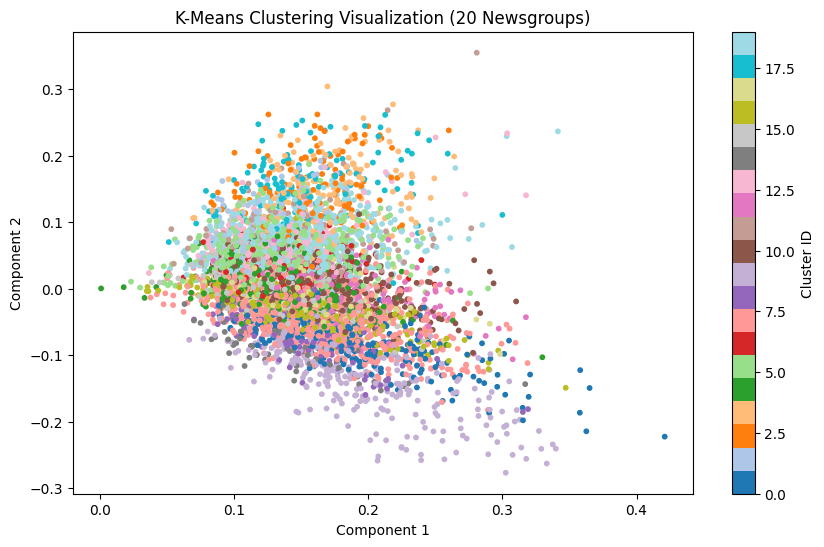

In [18]:
# Reduce high-dimensional TF-IDF feature space into 2 dimensions for visualization
svd = TruncatedSVD(n_components=2, random_state=42)

# Apply SVD transformation to convert TF-IDF matrix into 2D representation
X_2d = svd.fit_transform(X_tfidf)

# Create Scatter plot of clusters with setting plot size
plt.figure(figsize=(10,6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap='tab20', s=10)
#Add title and label of axis
plt.title("K-Means Clustering Visualization (20 Newsgroups)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster ID")#add colorbar
plt.show()#display plot

**Interpretation of K-Means Results:**

- The K-Means clustering results on the 20 Newsgroups dataset reveal several meaningful topic-based groupings, although some overlap between clusters is present, as indicated by the low silhouette score (0.01), which is common in high-dimensional text data.

- Despite this, the clusters show strong interpretability when analyzed using top terms like one cluster clearly represents sports discussions with words like 'game,' ''team,' and 'hockey, while another reflects computer hardware topics such as 'drive,' 'disk,' and 'controller.'

- Similarly, distinct clusters were formed for religion (e.g 'god,' 'jesus,' 'bible'), space and NASA-related content (e.g. 'space,' 'shuttle,' 'mission'), and politics involving Middle Eastern issues (e.g., “israel,” “arab,” “peace”).
- Several clusters also represent technology-related discussions such as operating systems, graphics cards and encryption, showing the dataset's strong technical bias.

- However, a few clusters mainly capture generic discussion patterns like 'writes,' 'article,' and 'subject,' which are due to the structure of newsgroup messages rather than specific topics.

- Overall, the clustering model successfully identified latent themes within the dataset, demonstrating that K-Means can effectively group similar documents even in unlabelled and noisy text data.

# Task-4: Model Evaluation and Prediction

**Applicability of the clustering model to new, unseen documents to predict their cluster assignments**

Note: TF-IDF is used for unseen documents to ensure they are represented in the same feature space as the training data. Since the K-Means model is trained on TF-IDF vectors, applying the same transformation allows consistent similarity measurement with cluster centroids. It also highlights important words while reducing common ones, improving accurate topic-based clustering.

In [19]:
# Create new unseen text documents for testing the clustering model
new_docs = [
    "The new graphics card improves gaming performance significantly.",
    "NASA launched a new satellite into space."
]

# Apply the same preprocessing steps to new documents
clean_new_docs = [preprocess_text(doc) for doc in new_docs]

# Convert new documents into TF-IDF feature vectors
new_features = tfidf_vectorizer.transform(clean_new_docs)

# Predict which cluster each new document belongs to
predicted_clusters = kmeans.predict(new_features)

print("New Document Predictions:")

# Loop through each document and its predicted cluster
for doc, cluster in zip(new_docs, predicted_clusters):
    # Display the original document with assigned cluster number
    print(f"Document: {doc}")
    print(f"Assigned Cluster: {cluster}\n")

New Document Predictions:
Document: The new graphics card improves gaming performance significantly.
Assigned Cluster: 18

Document: NASA launched a new satellite into space.
Assigned Cluster: 17



**Interpretation of Unseen Data Result:**

- The model is able to generalize well to unseen documents.
- It correctly maps new texts to the most similar topic clusters based on TF-IDF similarity.
- Assignments are logically consistent with cluster themes as graphics hardware reltate to Cluster 18 and space relate to Cluster 17. This indicates that the clustering model has learned meaningful topic structures from the dataset.